
## MACHINE LEARNING IN FINANCE
MODULE 6 | LESSON 3


---



# **OPTIMIZATION**

|  |  |
|:---|:---|
|**Reading Time** |  65 minutes |
|**Prior Knowledge** | Introduction to deep learning |
|**Keywords** |Gradient descent, stochastic gradient descent, convexity   |


---

*In the first lesson, we discussed gradient descent as an optimization algorithm, used to update model parameters in order to achieve minimum loss function. In this lesson, we will study some commonly used deep learning optimization algorithms.*



## **1. Optimization and Deep Learning**

In the first lesson, we saw that given a deep learning problem, we first define a loss function then use an optimization algorithm to minimize the loss function in a dataset. While optimization's major concern is to minimize an objective function, deep learning algorithms' primary concern is to minimize the difference between our model predictions and the label we want to predict, thus allowing the neural networks to achieve better performance. This is achieved by ensuring the model does not overfit the dataset.

We will now discuss the challenges of optimization in deep learning.




### **1.1 Local Minima**

Given an objective function $f(x)$, we define the **global minimum** as the value of $f(x)$ where the loss function is the minimum over the entire domain of the loss function, while a **local minimum** is found where, given a small segment of the domain, the value of $f(x)$ will be smaller at the local minimum than at any other point in the segment.

As discussed earlier, neural networks tend to be complex due to the non-linear activation functions we introduce at different layers. Therefore, the resultant loss function has more than one minimum as shown below:


**Figure 1:The Difference between a Global Minimum and Local Minimum**

<img src="https://d2l.ai/_images/output_optimization-intro_70d214_39_0.svg" alt="DDSP Tone Transfer" width="700">

##### Source: [Zhang, Aston, et al. "Dive into deep learning." arXiv preprint arXiv:2106.11342 (2021). ](https://d2l.ai/chapter_optimization/optimization-intro.html)

Imagine we have a ball and our target is to slide it to the lowest point in the curve above. If we started from the left side of the curve, the ball may settle in the first trough called a local minimum. We will not have achieved our target because the ball will not have reached the lowest possible point in this curve.

This is the scenario played by our deep learning algorithm. The best output will be achieved only when the model reaches the lowest possible point, which is called a global minimum. Otherwise, if it hits a local minimum, iterations will stop but not at an optimal point. We can escape this local minimum problem by introducing randomness in our algorithm.

A similar issue is the saddle point, which we explore next.






### **1.2 Saddle Points**

Saddle points are points in a function where the gradient is equal to zero, yet these points are neither a minimum nor a maximum value of the loss function. As such, the optimization algorithm tends to stall at these points as the gradient is zero. Below is a diagram depicting a saddle point.


**Figure 2 Saddle Point (Neither a Maximum nor a Minimum Point)**

<img src="https://d2l.ai/_images/output_optimization-intro_70d214_51_0.svg" alt="DDSP Tone Transfer" width="700">

##### Source: [Zhang, Aston, et al. "Dive into deep learning." arXiv preprint arXiv:2106.11342 (2021). ](https://d2l.ai/chapter_optimization/optimization-intro.html)

As mentioned in the previous subsection, by introducing randomness in our algorithm, we can escape the saddle points obstacle.

Finally, the other problem we face with deep learning optimization is vanishing gradients.<span style='color: transparent; font-size:1%'>All rights reserved WQU WorldQuant University QQQQ</span>

### **1.3 Vanishing Gradients**

Some of the activation functions we use in deep learning tend to give us zero or values close to zero at some points. This has the unintended consequence of getting the optimization algorithm stuck at these points for a while. To handle such cases, we can reparameterize the problem. Below is an example of a vanishing gradient problem.


**Figure 3: A Vanishing Gradient Scenario: A Common Problem with tanh Functions**

<img src="https://d2l.ai/_images/output_optimization-intro_70d214_75_0.svg" alt="DDSP Tone Transfer" width="700">

##### Source: [Zhang, Aston, et al. "Dive into deep learning." arXiv preprint arXiv:2106.11342 (2021). ](https://d2l.ai/chapter_optimization/optimization-intro.html)



In this section, we have looked at the challenges we face with optimization and how to handle them. In the next section, we are going to discuss functions that are easily solved by optimization algorithms called **convex functions**.




## **2. Convexity**

As we have seen so far, optimization algorithms play a critical role in machine learning when estimating the weights by minimizing the cost function.

Whilst studying gradient descent, we learned that the intuition behind it was to find weights that converge to a solution. These can either be a local minimum in the neighborhood or, if we are lucky, the global minimum. Understanding convexity prepares us to better understand gradient descent and generally the convergence problem. 



### **2.1 Convex Sets**

We can define a convex set as a shape in which, given any line that joins two points in this set, will never pass outside the set. See the diagrams below.

**Fig. 4: Convex and Non-Convex Sets**

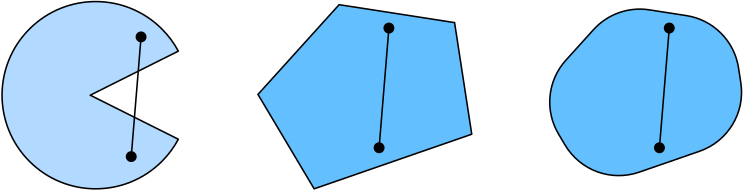

##### Source: [Zhang, Aston et al. "Dive into Deep Learning." https://d2l.ai/chapter_optimization/convexity.html

In the square and circle shapes above, the line segments drawn are well confined within the shapes, and thus the two are examples of convex sets. The diagram on the left is a non-convex set since part of the line segment passes outside the shape. 

Mathematically, a convex set $C$ is given by $$\alpha x + (1-\alpha) y \in C$$, $\forall x, y \in C$ and $\forall \alpha \in [0, 1]$

Next, we study convex functions, which are our main area of focus since we are interested in minima of loss functions.




### **2.2 Convex Functions**

We say that a function $f$ is convex if the set of points that are lying on or above the graph of the function is a convex set. Mathematically, if we have a convex set $C$, a function $f: C\rightarrow \mathbb{R}$ is said to be convex if for all $x, y \in C$ and $\alpha \in [0,1]$ then $$\alpha f(x) + (1-\alpha) f(y) \geq f(\alpha x + (1-\alpha)y)$$.

Most of the cost functions we will encounter are non-convex and we may need to test for the convexity of the function. Below are techniques we use to test whether a function is convex or not.

- A convex function has its second order derivative greater than or equal to zero, that is, $$f"(x) \geq 0$$ Examples are $y = e^x$ and $y = x^2$.

- If $-f"(x) \geq 0$, we call this function concave.

From  the above discussion it is clear that the local minimum of a convex function is the same as its global minimum.

In the next section, we seek to understand the role of convexity in gradient descent algorithms.



## **3. Gradient Descent**

In the first lesson, when training a neural network, we assigned initial weights randomly, and as such, we expect not to get accurate predictions. The aim of gradient descent was to assist us in getting the loss function at a minimum.

Once we initialize the weights and we are at a point $A$ in the loss curve below, we first check the direction that gives us the steepest decline in the loss function value. We take this direction, which is the direction opposite to the gradient's direction and it gives the direction with the steepest ascent.

**Fig. 5: Gradient Descent**

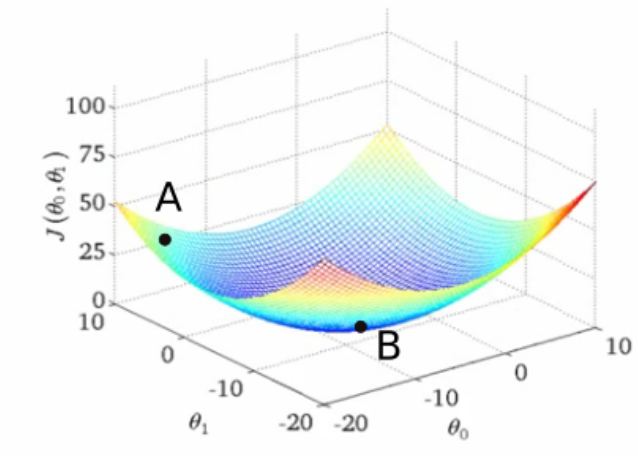


Now that we have the direction of the steepest ascent, we then choose the size of step to be taken in this direction. We call this step a **learning rate**. The learning rate must be chosen carefully to take us to the minimum. Large learning rates may cause the model to overshoot the minima as it bounces along the slopes of the function and never reaches the minimum, as in the path shown below.

**Fig. 6 A Plot of the Problem with Large Steps in Gradient Steps**

<img src="https://cdn.kastatic.org/ka-perseus-graphie/a795b84f1ca6c9424d5369664c1c9a59a3890adc.svg" alt="DDSP Tone Transfer" width="700">

##### Source: Khan Academy. "Gradient Descent." (https://www.khanacademy.org/math/multivariable-calculus/applications-of-multivariable-derivatives/optimizing-multivariable-functions/a/what-is-gradient-descent)



On the other hand, a small learning rate will make the model too slow, thus making the process infeasible. Another challenge with a small learning rate is that the model becomes stagnant toward a local minimum.

**Fig. 7 Gradient Steps with Small Step Sizes**

<img src="https://cdn.kastatic.org/ka-perseus-graphie/3ce30304fcc4dfdd2cbd064fd129bd573d9bc10e.svg" alt="DDSP Tone Transfer" width="700">

##### Source: Khan Academy. "Gradient Descent." (https://www.khanacademy.org/math/multivariable-calculus/applications-of-multivariable-derivatives/optimizing-multivariable-functions/a/what-is-gradient-descent)


Once we get both the gradient and learning rate, the next step is to calculate the gradient at our new point in the loss curve and repeat the process iteratively.

The gradient not only gives us the steepest ascent direction, its magnitude tells us how steep the ascent/descent will be. At the base of the curve, we expect the gradient to be approximately zero. Note that in practice we rarely reach the minima, but we get to a flat region where the loss function is closest to the minimum that can be achieved, and even after many iterations, the loss values don't improve much. As such, we say our model has fully converged.

The equation that describes the above updated rule of gradient descent is: $$w \leftarrow w - \alpha \times \bigtriangledown_w \sum_{1}^m L_m (w) \hspace{10mm} (1)$$

We perform this update in every iteration where $w$ represents the weight's vector, and it is from this vector that we subtract the gradient of the loss function multiplied by the learning rate $\alpha$.

For better performance of the gradient descent, a widely adapted technique by practitioners is to have a varying learning rate where we start with a large learning rate, and as we approach the minimum, we use a smaller learning rate. This approach is referred to as **simulated annealing**, and we will discuss more of it in the computational finance course.

As mentioned before, optimization algorithms—which gradient descent is a part of—suffer some challenges such as local minima and saddle points. We also mentioned that we can overcome these challenges by introducing randomness in our algorithm. **Stochastic gradient descent (SGD)** is an example of a stochastic gradient descent algorithm in which random noise has been added. Let us see how it works.



## **4. Stochastic Gradient Descent**

In the previous section, we saw that gradient descent updates the weights using the algorithm below:

`for k in [1, number_iterations]:`
    
`    X[k+1] = X[k] - alpha * gradient L[X(k)]`

The limitation of this is, with a good choice of $\alpha$, it will work for convex functions, but that does not necessarily mean that they will generalize well. For the algorithm to provide better generalization, they should be able to work with non-convex functions as well. As seen earlier, if the loss function is non-convex and our initial weight guess is not close to the global minima, then the gradient descent would converge at a local minima.

**Fig. 8 A Demonstration of the Stochastic Gradient Descent**

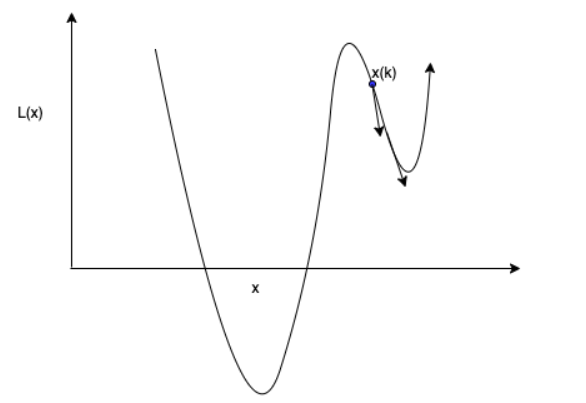

Stochastic gradient descent allows us to pick random samples in every iteration where we calculate the loss as shown below:

`for k in [1, number_iterations]:`

`    pick a random datapoint di;`

`    calculate loss Li`

`    X[k+1] = X[k] - alpha * gradient Li[X(k)]`

We expect the initial iterations of SGD to have a lot of noise; hence, the gradient will behave very erratically. This random loss behavior can allow the steps to escape the local minima curse. Other advantages of SGD over gradient descent are:

- SGD converges faster than gradient descent.
- SGD is convenient for training data coming in as streams.
- When we have very large datasets that can not be processed by RAM, SGD allows us to process smaller datasets at each iteration.

Another variant of the SGD that is commonly used is the **minibatch SGD**, which we ask students to study in the reference provided. 



## **5. Implementing Gradient Descent**

Gradient descent works well with convex functions. If $f$ is the convex function we would like to minimize, then at each iteration, our goal will be to get $f(x_{t+1}) \leq f(x_t)$. Therefore, gradient descent gradually computes the minimum of the cost function.

Below is a Python code implementation of gradient descent with a linear regression problem.

In [ ]:
# Importing Libraries
import matplotlib.pyplot as plt
import numpy as np

We first define the cost function, in this case the mean squared error, that gives the difference between the predicted value and the actual value given by the equation $$\text{Cost} = \frac{1}{n}\sum_1^n (y - \hat{y})^2 \hspace{10mm} (2)$$

In [ ]:
def MSE(y_true, y_predicted):
    # Calculating the loss or cost defined as MSE
    return np.sum((y_predicted - y_true) ** 2) / len(y_true)

We then define the gradient function below. The hyperparameters we consider are the number of iterations and learning rate, and we define the stopping threshold that will stop the iterations once we hit the threshold. The derivative of the cost function with respect to the weight is given by:
$$\frac{\partial \text{ cost}}{∂ W} = -\frac{2}{n}\sum_1^n x(y - \hat{y})$$

and the derivative of the cost function with respect to bias is 
$$\frac{\partial \text{ cost}}{∂ b} = -\frac{2}{n}\sum_1^n (y - \hat{y})$$

In [ ]:
def gradient_descent_algorithm(
    x, y, iterations=10000, alpha=0.0001, stopping_threshold=1e-7
):
    # Initializing weight, bias, learning rate and iterations
    weight = 0.1
    bias = 0.01
    iterations = iterations
    learning_rate = alpha
    n = float(len(x))

    costs = []
    weights = []
    previous_cost = None

    # Estimation of optimal parameters
    for i in range(iterations):
        # Making predictions
        y_predicted = (weight * x) + bias

        # Calculating the current cost
        cost = MSE(y, y_predicted)

        # If the change in cost is less than or equal to
        # stopping_threshold we stop the gradient descent
        if previous_cost and abs(previous_cost - cost) <= stopping_threshold:
            break

        previous_cost = cost

        costs.append(cost)
        weights.append(weight)

        # Calculating the gradients
        weight_derivative = -(2 / n) * sum(x * (y - y_predicted))
        bias_derivative = -(2 / n) * sum(y - y_predicted)

        # Updating weights and bias
        weight = weight - (learning_rate * weight_derivative)
        bias = bias - (learning_rate * bias_derivative)

        # Printing the parameters for each 1000th iteration
        # print(f"Iteration {i+1}: Cost {cost}, Weight \
        # {weight}, Bias {bias}")

    # Visualizing the weights and cost at for all iterations
    plt.figure(figsize=(8, 6))
    plt.plot(weights, costs)
    plt.scatter(weights, costs, marker="o", color="red")
    plt.title("Cost vs Weights")
    plt.suptitle(
        "Fig. 9: Cost vs Weights",
        fontweight="bold",
        horizontalalignment="right",
        fontsize=15,
    )
    plt.ylabel("Cost")
    plt.xlabel("Weight")
    plt.show()

    return weight, bias, cost

Below, we consider an example with the data:

In [ ]:
# Data
X = np.array(
    [
        3.66192704,
        0.4367313,
        3.86850312,
        0.28627004,
        0.64033297,
        1.84354183,
        3.51648513,
        2.33171731,
        2.40850115,
        1.0959004,
        3.24136739,
        0.39645735,
        2.44789746,
        0.01160215,
        2.02542692,
        0.19118386,
        2.07730598,
        0.10467331,
        0.50427978,
        3.04388398,
        2.01930518,
        2.5796251,
        2.47759331,
        3.86474532,
        2.51074925,
        2.8197363,
        1.83506425,
        1.01451347,
        1.48428389,
        1.0218188,
        2.85357911,
        1.54562156,
        0.04014026,
        0.02950905,
        1.9922938,
        2.48649378,
        0.20470277,
        2.88649838,
        3.02218141,
        1.62948796,
        2.46788939,
        1.26114926,
        0.74808066,
        0.95436498,
        2.26441095,
        1.00789754,
        1.18732863,
        3.91176711,
        1.0266336,
        2.32570421,
        2.80067965,
        0.83060144,
        3.85524446,
        2.50885513,
        3.04304448,
        1.90918746,
        2.80970553,
        1.97939314,
        0.26492414,
        2.16720092,
        3.74822112,
        2.72372863,
        2.6020474,
        2.61888224,
        0.02828909,
        1.65610441,
        0.41891066,
        3.36760303,
        2.0998768,
        1.98957548,
        1.43377349,
        2.22304239,
        0.24350151,
        2.52882744,
        0.25768373,
        0.85605071,
        2.3646854,
        3.09164147,
        2.87290517,
        2.83387608,
        0.30647763,
        0.68189712,
        0.38868718,
        2.23428206,
        3.74299469,
        1.54474145,
        1.08338491,
        3.96838634,
        0.98634429,
        3.03813934,
        1.45576515,
        3.25167005,
        1.11292405,
        3.71206365,
        2.31440203,
        3.16539218,
        0.87050119,
        3.04915131,
        3.16137918,
        2.05815803,
    ]
)
Y = np.array(
    [
        -3.33807296,
        -6.5632687,
        -3.13149688,
        -6.71372996,
        -6.35966703,
        -5.15645817,
        -3.48351487,
        -4.66828269,
        -4.59149885,
        -5.9040996,
        -3.75863261,
        -6.60354265,
        -4.55210254,
        -6.98839785,
        -4.97457308,
        -6.80881614,
        -4.92269402,
        -6.89532669,
        -6.49572022,
        -3.95611602,
        -4.98069482,
        -4.4203749,
        -4.52240669,
        -3.13525468,
        -4.48925075,
        -4.1802637,
        -5.16493575,
        -5.98548653,
        -5.51571611,
        -5.9781812,
        -4.14642089,
        -5.45437844,
        -6.95985974,
        -6.97049095,
        -5.0077062,
        -4.51350622,
        -6.79529723,
        -4.11350162,
        -3.97781859,
        -5.37051204,
        -4.53211061,
        -5.73885074,
        -6.25191934,
        -6.04563502,
        -4.73558905,
        -5.99210246,
        -5.81267137,
        -3.08823289,
        -5.9733664,
        -4.67429579,
        -4.19932035,
        -6.16939856,
        -3.14475554,
        -4.49114487,
        -3.95695552,
        -5.09081254,
        -4.19029447,
        -5.02060686,
        -6.73507586,
        -4.83279908,
        -3.25177888,
        -4.27627137,
        -4.3979526,
        -4.38111776,
        -6.97171091,
        -5.34389559,
        -6.58108934,
        -3.63239697,
        -4.9001232,
        -5.01042452,
        -5.56622651,
        -4.77695761,
        -6.75649849,
        -4.47117256,
        -6.74231627,
        -6.14394929,
        -4.6353146,
        -3.90835853,
        -4.12709483,
        -4.16612392,
        -6.69352237,
        -6.31810288,
        -6.61131282,
        -4.76571794,
        -3.25700531,
        -5.45525855,
        -5.91661509,
        -3.03161366,
        -6.01365571,
        -3.96186066,
        -5.54423485,
        -3.74832995,
        -5.88707595,
        -3.28793635,
        -4.68559797,
        -3.83460782,
        -6.12949881,
        -3.95084869,
        -3.83862082,
        -4.94184197,
    ]
)

# Using the gradient descent algorithm to find approximated weight and bias
weight, bias, cost = gradient_descent_algorithm(
    X, Y, iterations=1000, stopping_threshold=1e-5
)
print(f"Estimated Weight: {weight}\nEstimated Bias: {bias}")

# Making predictions using estimated parameters
Y_pred = weight * X + bias

# # Plotting the regression line
# plt.figure(figsize = (8,6))
# plt.scatter(X, Y, marker='o', color='red')
# plt.plot([min(X), max(X)], [min(Y_pred), max(Y_pred)], color='blue',markerfacecolor='red',
#          markersize=10,linestyle='dashed')
# `plt.xlabel`("X")
# `plt.ylabel`("Y")
# plt.show()

In [ ]:
plt.figure(figsize=(8, 6))
plt.scatter(X, Y, marker="o", color="red")
plt.plot(
    [min(X), max(X)],
    [min(Y_pred), max(Y_pred)],
    color="blue",
    markerfacecolor="red",
    markersize=10,
    linestyle="dashed",
)
plt.xlabel("X")
plt.ylabel("Y")
plt.suptitle(
    "Fig. 10: Linear Regression Prediction",
    fontweight="bold",
    horizontalalignment="right",
    fontsize=15,
)
plt.show()

## **6. Conclusion**

In this lesson, we have covered optimization in deep learning and extensively explored the gradient descent algorithm. We have also seen how easy it is to implement gradient descent. 

Now that we have introduced deep learning, in our next lesson, we will study an application of deep learning in predicting credit risk.



**References**

- Khan Academy. "Gradient Descent." https://www.khanacademy.org/math/multivariable-calculus/applications-of-multivariable-derivatives/optimizing-multivariable-functions/a/what-is-gradient-descent.

- Zhang, Aston et al. "Dive into Deep Learning." *arXiv* preprint arXiv:2106.11342, 2021, https://d2l.ai/d2l-en.pdf.

---
Copyright 2025 WorldQuant University. This
content is licensed solely for personal use. Redistribution or
publication of this material is strictly prohibited.
